# Analyse des ventes d'une boutique en ligne à l'aide de Pandas, NumPy et Matplotlib

## Définition du problème commercial

Notre magasin connaît une croissance rapide et enregistre un volume de transactions quotidiennes en constante augmentation. Pourtant, nous ne comprenons ni ces données de vente, ni leur valeur. Il existe certains problèmes tels qu'une gestion inefficace du stockage, un faible retour sur investissement marketing et un manque de stratégie d'expansion.

## Objectifs du projet

- Comprendre les tendances de vente
- Identifier les produits les plus vendus
- Analyser les comportements d'achat
- Proposer des recommandations pour améliorer les ventes

## Solution proposée

La solution consiste à consolider, nettoyer et analyser l'historique des ventes, à utiliser des outils d'analyse de données, à traiter les informations et à créer un rapport visuel qui présente clairement les résultats et les recommandations aux équipes de direction, de marketing et d'operations de vente (Sales Ops).

In [22]:
## Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

## Source des données

Les données de vente sont stockées dans un fichier CSV nommé `data/retail_store_sales.csv`, telechargé depuis Kaggle (https://www.kaggle.com/datasets/ahmedmohamed2003/retail-store-sales-dirty-for-data-cleaning)

In [23]:
sales_data = pd.read_csv('data/retail_store_sales.csv')
print(sales_data.head())

  Transaction ID Customer ID       Category          Item  Price Per Unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   

   Quantity  Total Spent  Payment Method Location Transaction Date  \
0      10.0        185.0  Digital Wallet   Online       2024-04-08   
1       9.0        261.0  Digital Wallet   Online       2023-07-23   
2       2.0         43.0     Credit Card   Online       2022-10-05   
3       9.0        247.5     Credit Card   Online       2022-05-07   
4       7.0         87.5  Digital Wallet   Online       2022-10-02   

  Discount Applied  
0             True  
1             True  
2            False  
3              NaN  
4          

In [24]:
sales_data.tail()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True
12574,TXN_2407494,CUST_23,Food,Item_9_FOOD,17.0,3.0,51.0,Cash,Online,2022-08-06,NaN


In [25]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [26]:
sales_data.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [27]:
sales_data.dtypes

Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Discount Applied     object
dtype: object

In [28]:
sales_data['Transaction Date'] = pd.to_datetime(sales_data['Transaction Date'])

In [29]:
sales_data['Revenue'] = sales_data['Quantity'] * sales_data['Price Per Unit']
print(sales_data.head())


  Transaction ID Customer ID       Category          Item  Price Per Unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   

   Quantity  Total Spent  Payment Method Location Transaction Date  \
0      10.0        185.0  Digital Wallet   Online       2024-04-08   
1       9.0        261.0  Digital Wallet   Online       2023-07-23   
2       2.0         43.0     Credit Card   Online       2022-10-05   
3       9.0        247.5     Credit Card   Online       2022-05-07   
4       7.0         87.5  Digital Wallet   Online       2022-10-02   

  Discount Applied  Revenue  
0             True    185.0  
1             True    261.0  
2            False     43.

In [30]:
top_10_products = sales_data.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(10)
top_10_products

Item
Item_2_BEV      676.0
Item_16_MILK    627.0
Item_25_FUR     616.0
Item_19_MILK    589.0
Item_13_FOOD    581.0
Item_5_FUR      581.0
Item_1_MILK     578.0
Item_11_MILK    574.0
Item_11_FUR     573.0
Item_14_FOOD    566.0
Name: Quantity, dtype: float64

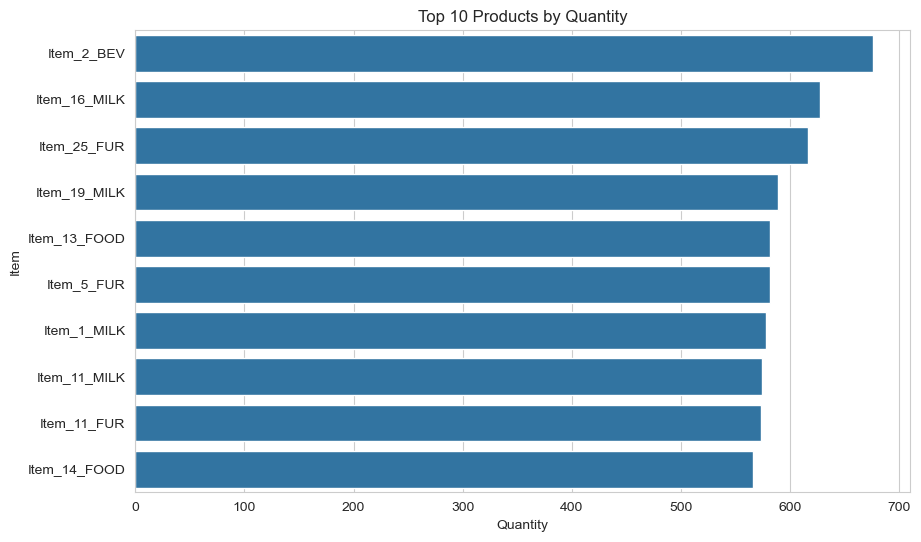

In [31]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
top_10_products = sales_data.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_10_products.values, y=top_10_products.index)
plt.title("Top 10 Products by Quantity")
plt.xlabel("Quantity")
plt.ylabel("Item")
plt.show()


## Analyse numéro deux - Revenus mensuels   

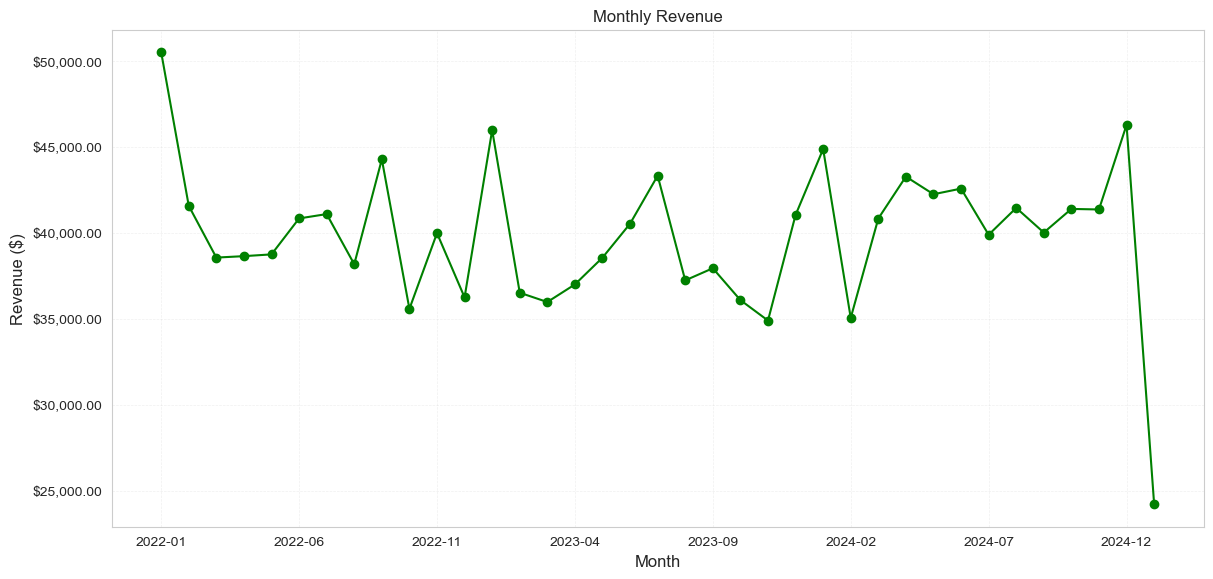

In [53]:
from shutil import which
import matplotlib.ticker as mticker


sales_data['Month'] = sales_data['Transaction Date'].dt.to_period('M')
monthly_revenue = sales_data.groupby('Month')['Revenue'].sum()
monthly_revenue.index = monthly_revenue.index.strftime('%Y-%m')
plt.figure(figsize=(12, 6))
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.2f}'))
plt.title('Monthly Revenue')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation = 45)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)
plt.tight_layout()
monthly_revenue.plot(kind='line', marker='o', linestyle='-', color='green')
plt.show()

# Références

1. https://www.datacamp.com/blog/etl-vs-elt